
## Assignment III – Section C: Programming Questions
### Local Search Algorithms: Hill Climbing, Simulated Annealing, Local Beam Search

In [1]:
from datetime import datetime
print(datetime.now())
print("F23-6014")  

2026-03-17 20:52:43.033244
F23-6014


---
## Q10: Hill Climbing Variants
**Function:** f(x) = −(x − 3)² + 9, maximization over real-valued x

In [5]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import random

print(datetime.now())
print("23F-6014")

# Objective function
def f(x):
    """f(x) = -(x-3)^2 + 9  |  Global max at x=3, f(3)=9"""
    return -(x - 3)**2 + 9

2026-03-17 21:02:59.147562
23F-6014


In [9]:
print(datetime.now())
print("23F-6014")

# Q10(a): Simple Hill Climbing

def simple_hill_climbing(x0=0.0, step=0.1):
    current = x0
    path = [current]
    print(f"\nSimple Hill Climbing (start={x0}) ")
    print(f"  Start: x={current:.4f}, f={f(current):.4f}")

    while True:
        improved = False
        for neighbor in [current + step, current - step]:
            if f(neighbor) > f(current):
                print(f"  Move: x={current:.4f} --> x={neighbor:.4f}  "
                      f"  f: {f(current):.4f} --> {f(neighbor):.4f}  ")
                current = neighbor
                path.append(current)
                improved = True
                break  # First-choice: take first improvement found

        if not improved:
            print(f"  Terminate: no improvement found.")
            print(f"  RESULT: x={current:.4f}, f(x)={f(current):.4f}")
            break

    return current, path

x_simple, path_simple = simple_hill_climbing(x0=0.0, step=0.1)

2026-03-17 21:04:59.197720
23F-6014

Simple Hill Climbing (start=0.0) 
  Start: x=0.0000, f=0.0000
  Move: x=0.0000 --> x=0.1000    f: 0.0000 --> 0.5900  
  Move: x=0.1000 --> x=0.2000    f: 0.5900 --> 1.1600  
  Move: x=0.2000 --> x=0.3000    f: 1.1600 --> 1.7100  
  Move: x=0.3000 --> x=0.4000    f: 1.7100 --> 2.2400  
  Move: x=0.4000 --> x=0.5000    f: 2.2400 --> 2.7500  
  Move: x=0.5000 --> x=0.6000    f: 2.7500 --> 3.2400  
  Move: x=0.6000 --> x=0.7000    f: 3.2400 --> 3.7100  
  Move: x=0.7000 --> x=0.8000    f: 3.7100 --> 4.1600  
  Move: x=0.8000 --> x=0.9000    f: 4.1600 --> 4.5900  
  Move: x=0.9000 --> x=1.0000    f: 4.5900 --> 5.0000  
  Move: x=1.0000 --> x=1.1000    f: 5.0000 --> 5.3900  
  Move: x=1.1000 --> x=1.2000    f: 5.3900 --> 5.7600  
  Move: x=1.2000 --> x=1.3000    f: 5.7600 --> 6.1100  
  Move: x=1.3000 --> x=1.4000    f: 6.1100 --> 6.4400  
  Move: x=1.4000 --> x=1.5000    f: 6.4400 --> 6.7500  
  Move: x=1.5000 --> x=1.6000    f: 6.7500 --> 7.0400  
  Mov

In [10]:
print(datetime.now())
print("23F-6014")


# Q10(b): Steepest-Ascent Hill Climbing

def steepest_ascent_hill_climbing(x0=0.0, step=0.1, verbose=True):
    current = x0
    path = [current]
    if verbose:
        print(f"\n Steepest-Ascent Hill Climbing (start={x0:.4f}) ")
        print(f"  Start: x={current:.4f}, f={f(current):.4f}")

    while True:
        neighbors = [current + step, current - step]
        best_neighbor = max(neighbors, key=f)

        if f(best_neighbor) > f(current):
            if verbose:
                print(f"  Move: x={current:.4f} → x={best_neighbor:.4f}  "
                      f"(f: {f(current):.4f} → {f(best_neighbor):.4f})")
            current = best_neighbor
            path.append(current)
        else:
            if verbose:
                print(f"  Terminate: both neighbors do not improve f.")
                print(f"  RESULT: x={current:.4f}, f(x)={f(current):.4f}")
            break

    return current, path

x_steep, path_steep = steepest_ascent_hill_climbing(x0=0.0, step=0.1)

2026-03-17 21:05:10.312241
23F-6014

 Steepest-Ascent Hill Climbing (start=0.0000) 
  Start: x=0.0000, f=0.0000
  Move: x=0.0000 → x=0.1000  (f: 0.0000 → 0.5900)
  Move: x=0.1000 → x=0.2000  (f: 0.5900 → 1.1600)
  Move: x=0.2000 → x=0.3000  (f: 1.1600 → 1.7100)
  Move: x=0.3000 → x=0.4000  (f: 1.7100 → 2.2400)
  Move: x=0.4000 → x=0.5000  (f: 2.2400 → 2.7500)
  Move: x=0.5000 → x=0.6000  (f: 2.7500 → 3.2400)
  Move: x=0.6000 → x=0.7000  (f: 3.2400 → 3.7100)
  Move: x=0.7000 → x=0.8000  (f: 3.7100 → 4.1600)
  Move: x=0.8000 → x=0.9000  (f: 4.1600 → 4.5900)
  Move: x=0.9000 → x=1.0000  (f: 4.5900 → 5.0000)
  Move: x=1.0000 → x=1.1000  (f: 5.0000 → 5.3900)
  Move: x=1.1000 → x=1.2000  (f: 5.3900 → 5.7600)
  Move: x=1.2000 → x=1.3000  (f: 5.7600 → 6.1100)
  Move: x=1.3000 → x=1.4000  (f: 6.1100 → 6.4400)
  Move: x=1.4000 → x=1.5000  (f: 6.4400 → 6.7500)
  Move: x=1.5000 → x=1.6000  (f: 6.7500 → 7.0400)
  Move: x=1.6000 → x=1.7000  (f: 7.0400 → 7.3100)
  Move: x=1.7000 → x=1.8000  (f: 7.310

In [11]:
print(datetime.now())
print("23F-6014")


# Q10(c): Random-Restart Hill Climbing

def random_restart_hill_climbing(n_restarts=10, step=0.1, x_range=(-10, 10)):
    print(f"\n Random-Restart Hill Climbing ({n_restarts} restarts) ")
    best_x = None
    best_f = -np.inf
    best_start = None
    all_paths = []
    all_starts = []

    random.seed(42)
    for i in range(n_restarts):
        start = random.uniform(*x_range)
        x_found, path = steepest_ascent_hill_climbing(x0=start, step=step, verbose=False)
        f_found = f(x_found)
        all_paths.append(path)
        all_starts.append(start)
        print(f"  Restart {i+1:2d}: start={start:7.3f} → x={x_found:.4f}, f={f_found:.4f}")

        if f_found > best_f:
            best_f = f_found
            best_x = x_found
            best_start = start

    print(f"\n  BEST SOLUTION: x={best_x:.4f}, f(x)={best_f:.4f}")
    print(f"  Best starting point: {best_start:.4f}")
    return best_x, best_f, best_start, all_paths, all_starts

best_x, best_f_val, best_start, all_paths, all_starts = random_restart_hill_climbing()

2026-03-17 21:05:28.739391
23F-6014

 Random-Restart Hill Climbing (10 restarts) 
  Restart  1: start=  2.789 → x=2.9885, f=8.9999
  Restart  2: start= -9.500 → x=3.0002, f=9.0000
  Restart  3: start= -4.499 → x=3.0006, f=9.0000
  Restart  4: start= -5.536 → x=2.9642, f=8.9987
  Restart  5: start=  4.729 → x=3.0294, f=8.9991
  Restart  6: start=  3.534 → x=3.0340, f=8.9988
  Restart  7: start=  7.844 → x=3.0436, f=8.9981
  Restart  8: start= -8.261 → x=3.0388, f=8.9985
  Restart  9: start= -1.562 → x=3.0384, f=8.9985
  Restart 10: start= -9.404 → x=2.9959, f=9.0000

  BEST SOLUTION: x=3.0002, f(x)=9.0000
  Best starting point: -9.4998


2026-03-17 21:05:47.538166
23F-6014


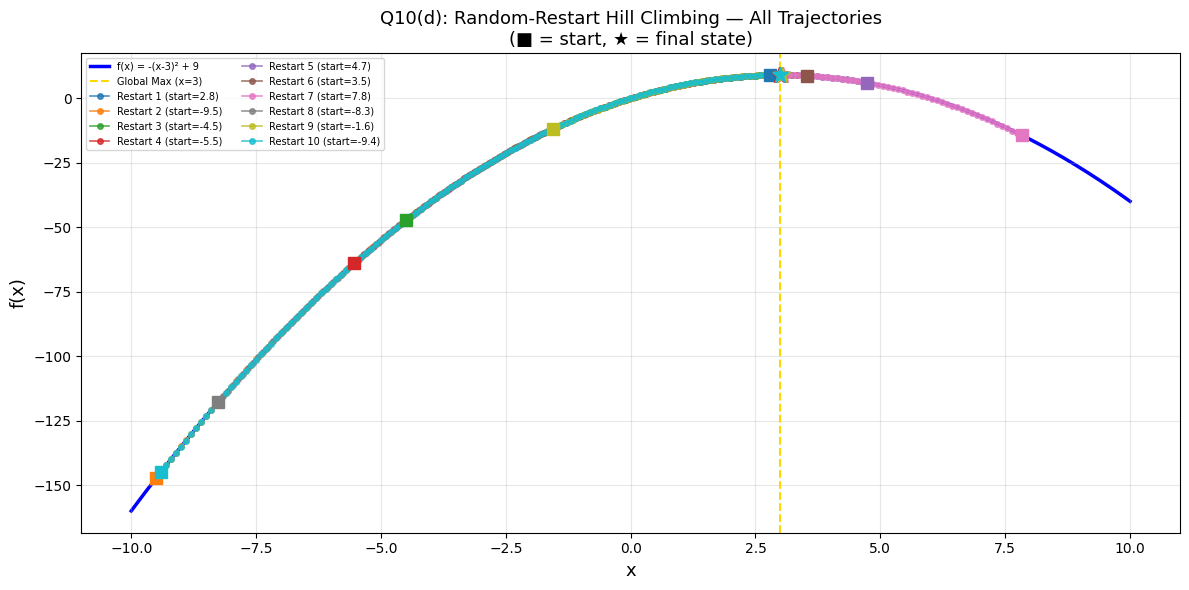


Discussion: Does random restart always help?
-------------------------------------------------------
For f(x) = -(x-3)^2 + 9 (unimodal, single peak at x=3):
  Random restart ALWAYS finds the global optimum here
  because the function has no local optima — every
  starting point's gradient leads to x=3.

When is it WASTEFUL?
  1. Unimodal functions (like this one): the first run
     already finds the global optimum; restarts add
     no value and waste computation.
  2. Very large continuous spaces: random starts may
     never land near the critical region.
  3. Expensive evaluations: each restart multiplies
     cost — SA or Beam Search may be more efficient.


In [12]:
print(datetime.now())
print("23F-6014")


# Q10(d): Plot all restart trajectories

x_vals = np.linspace(-10, 10, 500)
y_vals = [f(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='f(x) = -(x-3)² + 9', zorder=1)
ax.axvline(x=3, color='gold', linestyle='--', linewidth=1.5, label='Global Max (x=3)', zorder=2)

colors = plt.cm.tab10(np.linspace(0, 1, len(all_paths)))
for i, (path, start, col) in enumerate(zip(all_paths, all_starts, colors)):
    path_f = [f(p) for p in path]
    ax.plot(path, path_f, 'o-', color=col, markersize=4, linewidth=1.2,
            label=f'Restart {i+1} (start={start:.1f})', alpha=0.8, zorder=3)
    ax.plot(path[0], path_f[0], 's', color=col, markersize=8, zorder=4)
    ax.plot(path[-1], path_f[-1], '*', color=col, markersize=12, zorder=4)

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Q10(d): Random-Restart Hill Climbing — All Trajectories\n'
             '(■ = start, ★ = final state)', fontsize=13)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Discussion: Does random restart always help?")
print("-" * 55)
print("For f(x) = -(x-3)^2 + 9 (unimodal, single peak at x=3):")
print("  Random restart ALWAYS finds the global optimum here")
print("  because the function has no local optima — every")
print("  starting point's gradient leads to x=3.")
print()
print("When is it WASTEFUL?")
print("  1. Unimodal functions (like this one): the first run")
print("     already finds the global optimum; restarts add")
print("     no value and waste computation.")
print("  2. Very large continuous spaces: random starts may")
print("     never land near the critical region.")
print("  3. Expensive evaluations: each restart multiplies")
print("     cost — SA or Beam Search may be more efficient.")

---
## Q11: Simulated Annealing for TSP
10-city Travelling Salesman Problem solved with Simulated Annealing

In [13]:
from datetime import datetime
import math
import random
import numpy as np
import matplotlib.pyplot as plt

print(datetime.now())
print("23F-6014")

# ─────────────────────────────────────────
# City coordinates
# ─────────────────────────────────────────
CITIES = [(0,0), (1,5), (3,2), (6,4), (8,1),
          (7,7), (4,9), (2,7), (5,5), (9,3)]
N_CITIES = len(CITIES)

def euclidean_distance(c1, c2):
    return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

def tour_cost(tour):
    """Total distance of a tour, returning to start."""
    total = 0.0
    for i in range(N_CITIES):
        total += euclidean_distance(CITIES[tour[i]], CITIES[tour[(i+1) % N_CITIES]])
    return total

def get_neighbor(tour):
    """Swap two randomly chosen cities to generate a neighbor."""
    new_tour = tour[:]
    i, j = random.sample(range(N_CITIES), 2)
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

2026-03-17 21:05:57.292255
23F-6014


In [15]:
print(datetime.now())
print("23F-6014")

# ─────────────────────────────────────────
# Q11(b) & (c): SA algorithm
# ─────────────────────────────────────────
def simulated_annealing_tsp(T0=1000, alpha=0.995, n_iter=10_000,
                             seed=42, schedule='geometric'):

    random.seed(seed)

    # Initial state: random permutation
    current = list(range(N_CITIES))
    random.shuffle(current)
    current_cost = tour_cost(current)

    best = current[:]
    best_cost = current_cost

    T = T0
    delta = T0 / n_iter  # used only for linear cooling
    cost_history = [current_cost]

    for iteration in range(1, n_iter + 1):
        proposed = get_neighbor(current)
        proposed_cost = tour_cost(proposed)

        delta_e = current_cost - proposed_cost  # positive = improvement

        if delta_e > 0:
            # Better solution — always accept
            current = proposed
            current_cost = proposed_cost
        else:
            # Worse solution — accept with probability e
            if T > 1e-10:
                prob = math.exp(delta_e / T)
                if random.random() < prob:
                    current = proposed
                    current_cost = proposed_cost

        if current_cost < best_cost:
            best = current[:]
            best_cost = current_cost

        # Cooling
        if schedule == 'geometric':
            T *= alpha
        else:
            T = max(0, T - delta)

        cost_history.append(current_cost)

    return best, best_cost, cost_history


# Run with geometric cooling
best_tour, best_distance, cost_hist = simulated_annealing_tsp(
    T0=1000, alpha=0.995, n_iter=10_000, schedule='geometric')

print(" SA TSP Results ")
print(f"Best tour:      {best_tour}")
print(f"City sequence:  {' → '.join([str(CITIES[c]) for c in best_tour])} → {CITIES[best_tour[0]]}")
print(f"Total distance: {best_distance:.4f}")

2026-03-17 21:06:44.254894
23F-6014
 SA TSP Results 
Best tour:      [8, 2, 0, 1, 7, 6, 5, 9, 4, 3]
City sequence:  (5, 5) → (3, 2) → (0, 0) → (1, 5) → (2, 7) → (4, 9) → (7, 7) → (9, 3) → (8, 1) → (6, 4) → (5, 5)
Total distance: 32.7081


2026-03-17 21:06:55.033706
23F-6014


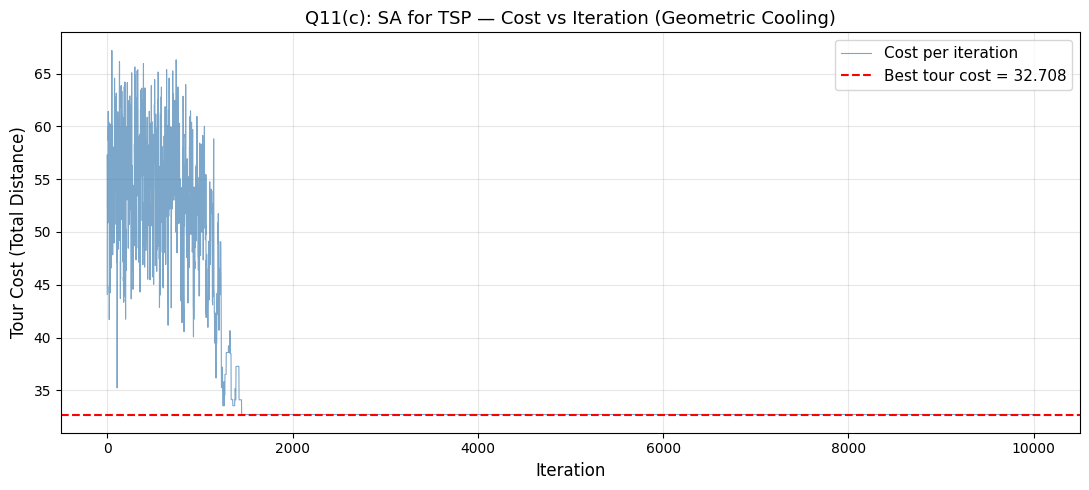

In [16]:
print(datetime.now())
print("23F-6014")

# Q11(c): Plot cost vs iteration

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cost_hist, color='steelblue', linewidth=0.8, alpha=0.7, label='Cost per iteration')
ax.axhline(y=best_distance, color='red', linestyle='--', linewidth=1.5,
           label=f'Best tour cost = {best_distance:.3f}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Tour Cost (Total Distance)', fontsize=12)
ax.set_title('Q11(c): SA for TSP — Cost vs Iteration (Geometric Cooling)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2026-03-17 21:07:05.969798
23F-6014


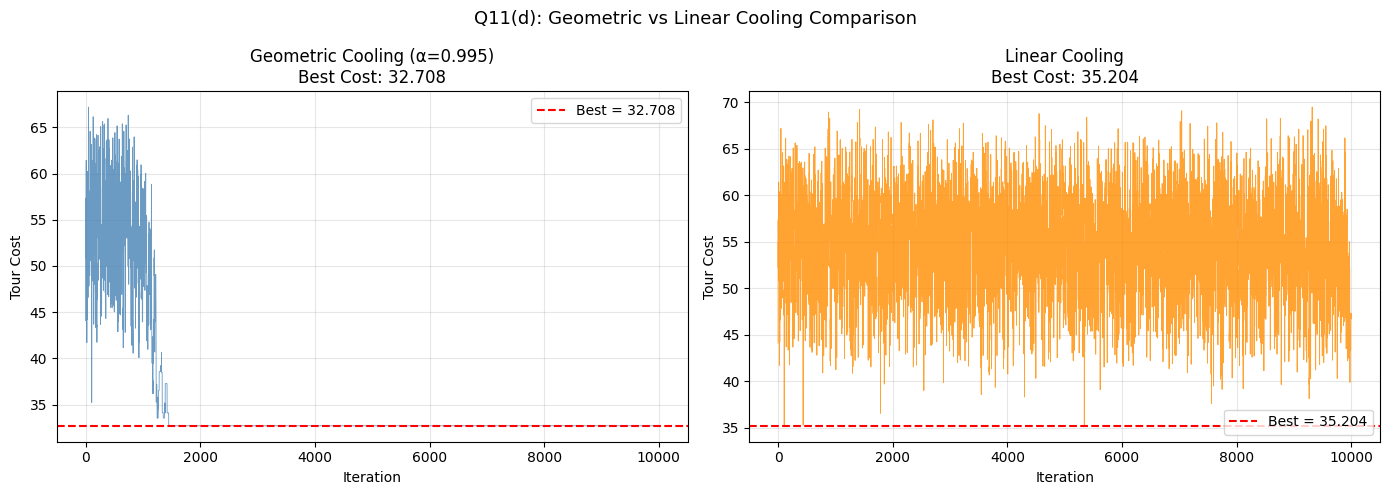

Geometric cooling — Best cost: 32.7081
Linear cooling    — Best cost: 35.2041

Observations:
  Geometric cooling keeps temperature higher for longer,
  preserving exploration before converging. This typically
  finds better solutions (lower cost) than linear cooling.
  Linear cooling drops temperature at a fixed rate, so it
  becomes greedy too early, getting stuck in local optima.
  Winner for this run: Geometric cooling.


In [17]:
print(datetime.now())
print("23F-6014")


# Q11(d): Geometric vs Linear cooling

_, cost_g, hist_g = simulated_annealing_tsp(schedule='geometric', seed=42)
_, cost_l, hist_l = simulated_annealing_tsp(schedule='linear', seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_g, color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].axhline(y=cost_g, color='red', linestyle='--', linewidth=1.5,
                label=f'Best = {cost_g:.3f}')
axes[0].set_title(f'Geometric Cooling (α=0.995)\nBest Cost: {cost_g:.3f}', fontsize=12)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Tour Cost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_l, color='darkorange', linewidth=0.6, alpha=0.8)
axes[1].axhline(y=cost_l, color='red', linestyle='--', linewidth=1.5,
                label=f'Best = {cost_l:.3f}')
axes[1].set_title(f'Linear Cooling\nBest Cost: {cost_l:.3f}', fontsize=12)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Tour Cost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Q11(d): Geometric vs Linear Cooling Comparison', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Geometric cooling — Best cost: {cost_g:.4f}")
print(f"Linear cooling    — Best cost: {cost_l:.4f}")
print()
print("Observations:")
print("  Geometric cooling keeps temperature higher for longer,")
print("  preserving exploration before converging. This typically")
print("  finds better solutions (lower cost) than linear cooling.")
print("  Linear cooling drops temperature at a fixed rate, so it")
print("  becomes greedy too early, getting stuck in local optima.")
winner = 'Geometric' if cost_g <= cost_l else 'Linear'
print(f"  Winner for this run: {winner} cooling.")

---
## Q12: Local Beam Search for N-Queens (N=8)
State: list of length 8 where state[i] = row of queen in column i  
Heuristic: h(state) = number of non-attacking pairs (maximize)  
Goal: h = N*(N-1)/2 = 28 (all pairs non-attacking)

In [20]:
from datetime import datetime
import random
import numpy as np

print(datetime.now())
print("23F-6014")


# Q12(a): State representation & heuristic

N = 8
GOAL_H = N * (N - 1) // 2  # = 28

def heuristic(state):
    """
    Count non-attacking pairs of queens.
    Total possible pairs = 28. Attacks reduce this count.
    """
    attacks = 0
    for i in range(N):
        for j in range(i + 1, N):
            if state[i] == state[j]:           # same row
                attacks += 1
            elif abs(state[i] - state[j]) == abs(i - j):  # same diagonal
                attacks += 1
    return GOAL_H - attacks

def get_successors(state):
    """All states from moving one queen to any other row in its column."""
    successors = []
    for col in range(N):
        for row in range(N):
            if row != state[col]:
                new_state = state[:]
                new_state[col] = row
                successors.append(new_state)
    return successors

def random_state():
    return [random.randint(0, N - 1) for _ in range(N)]

def is_goal(state):
    return heuristic(state) == GOAL_H

# Sanity check with a known solution
known = [0, 4, 7, 5, 2, 6, 1, 3]
print(f"Known solution h={heuristic(known)} (should be {GOAL_H}): {is_goal(known)}")

2026-03-17 21:07:52.216925
23F-6014
Known solution h=28 (should be 28): True


In [18]:
print(datetime.now())
print("23F-6014")


# Q12(b): Local Beam Search with k=5

def local_beam_search(k=5, max_iter=500):
    beams = [random_state() for _ in range(k)]

    for iteration in range(max_iter):
        # Check for goal
        for state in beams:
            if is_goal(state):
                return state, iteration, GOAL_H

        # Generate all successors from all beams
        all_successors = []
        for state in beams:
            all_successors.extend(get_successors(state))

        # Remove duplicates
        seen = set()
        unique = []
        for s in all_successors:
            t = tuple(s)
            if t not in seen:
                seen.add(t)
                unique.append(s)

        # Select top-k by heuristic
        unique.sort(key=heuristic, reverse=True)
        new_beams = unique[:k]

        # Convergence: no improvement across beams
        if max(heuristic(s) for s in new_beams) <= max(heuristic(s) for s in beams):
            best = max(new_beams, key=heuristic)
            return None, iteration, heuristic(best)

        beams = new_beams

    best = max(beams, key=heuristic)
    return None, max_iter, heuristic(best)

2026-03-17 21:07:28.558710
23F-6014


In [19]:
print(datetime.now())
print("23F-6014")


# Q12(c): Run 20 trials — statistics

from collections import Counter

random.seed(0)
N_TRIALS = 20
successes = 0
success_iters = []
failure_hs = []

print("Running 20 trials of Local Beam Search (k=5)...\n")
for trial in range(N_TRIALS):
    sol, iters, best_h = local_beam_search(k=5)
    if sol is not None:
        successes += 1
        success_iters.append(iters)
        print(f"  Trial {trial+1:2d}: SUCCESS  (iter={iters}, h={GOAL_H})")
    else:
        failure_hs.append(best_h)
        print(f"  Trial {trial+1:2d}: FAIL     (best h={best_h}/{GOAL_H})")

print(f"\n{'='*50}")
print(f"  (i)   Success rate: {successes}/{N_TRIALS} = {100*successes/N_TRIALS:.1f}%")
if success_iters:
    print(f"  (ii)  Avg iterations to success: {sum(success_iters)/len(success_iters):.1f}")
else:
    print(f"  (ii)  Avg iterations to success: N/A")
if failure_hs:
    most_common = Counter(failure_hs).most_common(1)[0]
    print(f"  (iii) Most common failure h: {most_common[0]} (occurred {most_common[1]} times)")
    print(f"        Failure mode: Beams lose diversity and cluster at the")
    print(f"        same local optimum (h={most_common[0]}), unable to escape.")

2026-03-17 21:07:38.207632
23F-6014
Running 20 trials of Local Beam Search (k=5)...



NameError: name 'random_state' is not defined

In [ ]:
print(datetime.now())
print("23F-6014")

# ─────────────────────────────────────────
# Q12(d): Stochastic Beam Search
# ─────────────────────────────────────────
def stochastic_beam_search(k=5, max_iter=500):
    """
    Instead of always picking top-k, sample k successors
    with probability proportional to heuristic value.
    This preserves beam diversity.
    """
    beams = [random_state() for _ in range(k)]

    for iteration in range(max_iter):
        for state in beams:
            if is_goal(state):
                return state, iteration, GOAL_H

        all_successors = []
        for state in beams:
            all_successors.extend(get_successors(state))

        # Remove duplicates
        seen = set()
        unique = []
        for s in all_successors:
            t = tuple(s)
            if t not in seen:
                seen.add(t)
                unique.append(s)

        if len(unique) < k:
            beams = unique
            continue

        # Compute sampling probabilities proportional to heuristic
        h_vals = [heuristic(s) for s in unique]
        min_h = min(h_vals)
        weights = [h - min_h + 1 for h in h_vals]  # shift to ensure all positive
        total = sum(weights)
        probs = [w / total for w in weights]

        # Sample k states without replacement
        indices = np.random.choice(len(unique), size=k, replace=False, p=probs)
        new_beams = [unique[i] for i in indices]

        if max(heuristic(s) for s in new_beams) <= max(heuristic(s) for s in beams):
            best = max(new_beams, key=heuristic)
            return None, iteration, heuristic(best)

        beams = new_beams

    best = max(beams, key=heuristic)
    return None, max_iter, heuristic(best)


# Run 20 trials
random.seed(0)
np.random.seed(0)
s_successes = 0
s_success_iters = []

print("Running 20 trials of Stochastic Beam Search (k=5)...\n")
for trial in range(N_TRIALS):
    sol, iters, best_h = stochastic_beam_search(k=5)
    if sol is not None:
        s_successes += 1
        s_success_iters.append(iters)
        print(f"  Trial {trial+1:2d}: SUCCESS  (iter={iters})")
    else:
        print(f"  Trial {trial+1:2d}: FAIL     (best h={best_h}/{GOAL_H})")

print(f"\n{'='*50}")
print(f"COMPARISON — Standard vs Stochastic Beam Search")
print(f"{'='*50}")
print(f"  Standard   success rate: {successes}/{N_TRIALS} = {100*successes/N_TRIALS:.1f}%")
print(f"  Stochastic success rate: {s_successes}/{N_TRIALS} = {100*s_successes/N_TRIALS:.1f}%")
if success_iters:
    print(f"  Standard   avg iters: {sum(success_iters)/len(success_iters):.1f}")
if s_success_iters:
    print(f"  Stochastic avg iters: {sum(s_success_iters)/len(s_success_iters):.1f}")
print()
print("  Discussion:")
print("  Standard LBS always picks the deterministic top-k,")
print("  causing all beams to cluster at the same local maximum.")
print("  Stochastic selection maintains diversity by occasionally")
print("  including lower-ranked states, allowing beams to explore")
print("  different regions. Trade-off: may take more iterations.")